#  <center> Taller  de Aprendizaje Automático </center>
##  <center> Taller 9: *Natural Language Processing* (NLP)  </center>

## Introducción

La siguiente actividad propone el abordaje de un problema de procesamiento de lenguaje natural (NLP) utilizando herramientas de *embedding* y modelos RNN. El conjunto de datos que se utilizará es IMDb, el cual corresponde a un problema de clasificación donde se tienen 50000 criticas de películas (35000 de *train* y 15000 de *test*), y se quiere estimar si éstas son críticas positivas (1) o negativas (0).

La propuesta consiste en entender y reproducir los pasos de la sección *Sentiment Analysis* para los datos **sin procesar**, agregando algunas variantes como mitigar el sobreajuste y entender la herramienta *embeddings*.

En este Taller también se introduce la biblioteca *Streamlit*, utilizada para desarrollar prototipos de aplicaciones web de aprendizaje automático. Aquellos que así lo deseen, podrán generar de manera sencilla una aplicación web que clasifique las críticas proporcionadas por los usuarios. Además, se presenta la biblioteca HuggingFace, la cual permite realizar inferencias con modelos preentrenados y realizar fine-tuning para adaptarlos a esta tarea específica.

## Objetivos


*   Aplicar modelos basados en RNN a un problema de NLP.
*   Trabajar con embeddings para secuencias de texto, en particular embeddings preentrenados.
*   Utilizar herramientas para la visualización de embeddings.
*  (Opcional, no evaluado) Desarrollar una aplicación web que clasifique críticas proporcionadas por los usarios
*  (Opcional, no evaluado) Utilizar la biblioteca *HuggingFace* para utilizar modelos preentrenados y realizar fine-tunning.

## Formas de trabajo

### Opción 1: Trabajar localmente

Descargar los datos en su máquina personal y trabajar en su propio ambiente de desarrollo.

`conda activate TAA-py310`              
`jupyter-notebook`    

Los paquetes faltantes se pueden instalar desde el notebook haciendo:     
` !pip install paquete_faltante`

### Opción 2:  Trabajar en *Colab*.

<table align="center">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/TAA-fing/TAA-2025/blob/main/talleres/taller9_NLP.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Ejecutar en Google Colab</a>
  </td>
</table>

Se puede trabajar en Google Colab. Para ello es necesario contar con una cuenta de **google drive** y ejecutar un notebook almacenado en dicha cuenta. De lo contrario, no se conservarán los cambios realizados en la sesión. En caso de ya contar con una cuenta, se puede abrir el notebook y luego ir a `Archivo-->Guardar una copia en drive`.

La siguiente celda realiza la configuración necesaria para obtener datos desde la plataforma Kaggle. Le solicitará que suba el archivo *kaggle.json* asociado a su cuenta.

In [1]:
import warnings
warnings.filterwarnings('ignore')
from google.colab import files

# El siguiente archivo solicitado es para habilitar la API de Kaggle en el entorno que está trabajando.
# Este archivo se descarga entrando a su perfíl de Kaggle, en la sección API, presionando donde dice: Create New API Token

uploaded = files.upload()

for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

#Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 74 bytes


# Parte 1: Análisis y preprocesamiento de datos


Se utilizará el conjunto de IMDb provisto por Kaggle. Se tienen 50000 criticas de películas que al igual que en el *Taller 2* se utilizarán 35000 para *train* y 15000 para *test*.

*   Ejecutar la siguiente celda para descargar el conjunto y verificar que los conjuntos tienen la cantidad de instancias esperadas.

In [2]:
# Descarga la base IMDb de Kaggle
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other
imdb-dataset-of-50k-movie-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [15]:
import zipfile
import pandas as pd
from tensorflow.keras.layers import TextVectorization
import tensorflow as tf
import tensorflow_datasets as tfds
import string
import re

# Se descomprime el archivo descargado
with zipfile.ZipFile('imdb-dataset-of-50k-movie-reviews.zip', 'r') as zip_ref:
    zip_ref.extractall('')

# Se levanta como pandas DataFrame
data_file = 'IMDB Dataset.csv'
data = pd.read_csv(data_file)

#Separación de Conjuntos
N=35000
X_train = data.loc[:N-1, 'review'].values
y_train = data.loc[:N-1, 'sentiment'].values == 'positive'
X_test = data.loc[N:, 'review'].values
y_test = data.loc[N:, 'sentiment'].values == 'positive'

# Armado de los Tensorflow Datasets
data_train = tf.data.Dataset.from_tensor_slices((X_train, y_train))
data_test = tf.data.Dataset.from_tensor_slices((X_test, y_test))

#Verificación
print('Train Size:', len(data_train),'Test Size:', len(data_test))

Train Size: 35000 Test Size: 15000


*   Del conjunto de entrenamiento visualizar tanto una review positiva como una negativa. Se sugiere ir a los Notebooks del *Capítulo 16*. Puede ser útil el uso del método *.skip()*.

In [18]:
# Visualizar una review positiva
print("=== REVIEW POSITIVA ===")
pos_found = False
for review, label in data_train:
    if label.numpy() == 1:
        print(review.numpy().decode("utf-8")[:500])
        print("Label:", label.numpy())
        pos_found = True
        break
if not pos_found:
    print("No se encontró review positiva en el primer segmento.")

print("\n" + "="*60 + "\n")

# Visualizar una review negativa
print("=== REVIEW NEGATIVA ===")
neg_found = False
for review, label in data_train:
    if label.numpy() == 0:
        print(review.numpy().decode("utf-8")[:500])
        print("Label:", label.numpy())
        neg_found = True
        break
if not neg_found:
    print("No se encontró review negativa en el primer segmento.")

=== REVIEW POSITIVA ===
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ
Label: True


=== REVIEW NEGATIVA ===
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real l

*   Reservar unas 5000 críticas de los datos de entrenamiento para validación.

In [20]:
# Reservar 5000 críticas de los datos de entrenamiento para validación
VALIDATION_SIZE = 5000

# Dividir el conjunto de entrenamiento
data_train_shuffled = data_train.shuffle(buffer_size=len(data_train), seed=42)
data_validation = data_train_shuffled.take(VALIDATION_SIZE)
data_train_final = data_train_shuffled.skip(VALIDATION_SIZE)

# Verificar los tamaños
print(f"Conjunto de entrenamiento final: {len(data_train_final)}")
print(f"Conjunto de validación: {len(data_validation)}")
print(f"Conjunto de test: {len(data_test)}")

Conjunto de entrenamiento final: 30000
Conjunto de validación: 5000
Conjunto de test: 15000


* Prepare los batches para todos los conjuntos

In [31]:
# Preparar los batches para todos los conjuntos
BATCH_SIZE = 32

# Crear batches para cada conjunto
data_train_batched = data_train_final.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
data_validation_batched = data_validation.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
data_test_batched = data_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print(f"Batches de entrenamiento: {len(data_train_batched)}")
print(f"Batches de validación: {len(data_validation_batched)}")
print(f"Batches de test: {len(data_test_batched)}")

Batches de entrenamiento: 938
Batches de validación: 157
Batches de test: 469


In [34]:
def preprocess(X_batch, y_batch):
  X_batch = tf.strings.substr(X_batch, 0, 300)
  X_batch = tf.strings.regex_replace(X_batch, rb"<br\s*/?>", b" ")
  X_batch = tf.strings.regex_replace(X_batch, b"[^a-zA-Z']", b" ")
  X_batch = tf.strings.split(X_batch)
  return X_batch.to_tensor(default_value=b"<pad>"), y_batch

In [35]:
# Aplicar la función preprocess a los datasets batched

data_train_preprocessed = data_train_batched.map(preprocess)
data_validation_preprocessed = data_validation_batched.map(preprocess)
data_test_preprocessed = data_test_batched.map(preprocess)

# Mostrar un ejemplo de batch preprocesado
for X_batch, y_batch in data_train_preprocessed.take(1):
    print("Ejemplo de batch preprocesado:")
    print("Forma de X_batch:", X_batch.shape)
    print("Primeras 2 secuencias:", X_batch[:2])
    print("Primeras 2 etiquetas:", y_batch[:2])

Ejemplo de batch preprocesado:
Forma de X_batch: (32, 62)
Primeras 2 secuencias: tf.Tensor(
[[b'The' b'nearest' b'I' b'ever' b'came' b'to' b'seeing' b'this' b'was'
  b'a' b'clip' b'shown' b'at' b'a' b'Gerard' b'Philippe' b'exposition'
  b'in' b'Paris' b'about' b'two' b'years' b'ago' b'I' b'had' b'no'
  b'interest' b'in' b'the' b'remake' b'and' b'having' b'just' b'caught'
  b'up' b'with' b'the' b'original' b'just' b'over' b'half' b'a'
  b'century' b'after' b'it' b'was' b'made' b'I' b'can' b'only'
  b'conclude' b'that' b'the' b'inept' b'fencing' b'was' b'intentional'
  b'aim' b'<pad>' b'<pad>' b'<pad>' b'<pad>']
 [b'This' b'is' b'a' b'thoroughly' b'diabolical' b'tale' b'of' b'just'
  b'how' b'bad' b'things' b'can' b'go' b'wrong' b'A' b'simple' b'robbery'
  b'Pick' b'up' b'some' b'serious' b'change' b'Get' b'our' b'finances'
  b'together' b'and' b'everything' b'will' b'be' b'hunky' b'dory' b'But'
  b'mom' b'and' b"pop's" b'jewelry' b'store' b'No' b'problem'
  b'Insurance' b'pays' b'for' b

*   Keras proporciona una capa de `TextVectorization` para el preprocesamiento básico de texto. Explique el funcionamiento y adapte una capa para los datos de entrenemiento en cuestión. Se sugiere leer la sección asociada a esta capa en el *Capítulo 13* del libro. Utilice un tamaño de vocabulario de 10000 palabras.


# Explicación Detallada de TextVectorization

La capa **TextVectorization** de Keras es fundamental para el preprocesamiento de texto en NLP. Su funcionamiento se divide en varias etapas:

### 1. ESTANDARIZACIÓN (standardize)
- Convierte el texto a minúsculas por defecto
- Elimina signos de puntuación
- Puede personalizarse con una función propia

### 2. TOKENIZACIÓN (split)
- Divide el texto en palabras/tokens (por defecto usa espacios)
- Se puede personalizar con funciones propias

### 3. CONSTRUCCIÓN DEL VOCABULARIO (adapt)
- Cuenta la frecuencia de cada palabra en los datos de entrenamiento
- Ordena las palabras por frecuencia descendente
- Asigna índices únicos a cada palabra (empezando desde 2)
- Reserva **0 para padding** y **1 para palabras desconocidas**

### 4. CODIFICACIÓN
- Convierte cada palabra a su índice correspondiente
- Palabras no vistas se codifican como 1 (desconocidas)
- Se aplica padding con 0s para igualar longitudes

### 5. OPCIONES DE SALIDA (output_mode)
- **'int'**: secuencias de enteros (más común para RNNs)
- **'multi_hot'**: codificación one-hot multi-clase
- **'count'**: conteo de frecuencias
- **'tf_idf'**: term-frequency × inverse-document-frequency

### Ejemplo Básico del Funcionamiento

```python
train_data = ["To be", "!(to be)", "That's the question", "Be, be, be."]
text_vec = TextVectorization()
text_vec.adapt(train_data)
# Resultado: "be"=2, "to"=3, "that"=4, "the"=5, "question"=6
```

### Comparación de Modos de Salida

| Modo | Descripción | Uso Ideal |
|------|-------------|-----------|
| `'int'` | Secuencias de enteros | RNNs, LSTMs, GRUs - preserva orden |
| `'multi_hot'` | Vector binario (0/1) | Modelos de bolsa de palabras |
| `'tf_idf'` | Ponderación por frecuencia | Clasificación de texto simple |

### Para Nuestro Problema de Análisis de Sentimientos
- **Usamos modo 'int'** porque entrenaremos una RNN
- **El orden de las palabras importa** para determinar el sentimiento
- **Aplicaremos Embedding** después de la vectorización

In [39]:
# Configurar la capa TextVectorization usando la función preprocess
VOCAB_SIZE = 10000

def custom_standardization(text):
    # Eliminar etiquetas HTML
    text = tf.strings.regex_replace(text, '<br />', ' ')
    # Pasar a minúsculas
    text = tf.strings.lower(text)
    # Eliminar puntuación
    text = tf.strings.regex_replace(text, f'[{re.escape(string.punctuation)}]', '')
    return text

text_vectorizer = TextVectorization(
    standardize=custom_standardization,
    max_tokens=VOCAB_SIZE,
    output_mode='int'
)

# Adaptar la capa a los datos de entrenamiento (solo textos, no etiquetas)
# Extraer los textos del dataset de entrenamiento
train_texts = data_train_final.map(lambda x, y: x)
text_vectorizer.adapt(train_texts)

# Demostración práctica del funcionamiento
example_text = "This movie was <br /> absolutely wonderful! I loved it."
vectorized = text_vectorizer([example_text])
print(f"Texto original: {example_text}")
print(f"Vectorizado: {vectorized.numpy()[0][:20]}")
print(f"Longitud de la secuencia: {len(vectorized.numpy()[0])}")

Texto original: This movie was <br /> absolutely wonderful! I loved it.
Vectorizado: [ 11  17  13 400 373  10 433   9]
Longitud de la secuencia: 8


* Obtenga el diccionario de la capa `TextVectorization`

In [41]:
# Obtener el diccionario de la capa TextVectorization
vocab = text_vectorizer.get_vocabulary()

print(f"Tamaño del vocabulario: {len(vocab)}")
print("\n=== Primeras 20 palabras del vocabulario ===")
for i, word in enumerate(vocab[:20]):
    print(f"{i}: '{word}'")

print("\n=== Últimas 20 palabras del vocabulario ===")
for i, word in enumerate(vocab[-20:], len(vocab)-20):
    print(f"{i}: '{word}'")

# Crear diccionario palabra -> índice
word_to_index = {word: i for i, word in enumerate(vocab)}

# Crear diccionario índice -> palabra
index_to_word = {i: word for i, word in enumerate(vocab)}

print(f"\nEjemplos de mapeo:")
print(f"'the' -> {word_to_index.get('the', 'No encontrada')}")
print(f"'movie' -> {word_to_index.get('movie', 'No encontrada')}")
print(f"'good' -> {word_to_index.get('good', 'No encontrada')}")
print(f"'bad' -> {word_to_index.get('bad', 'No encontrada')}")

Tamaño del vocabulario: 10000

=== Primeras 20 palabras del vocabulario ===
0: ''
1: '[UNK]'
2: 'the'
3: 'and'
4: 'a'
5: 'of'
6: 'to'
7: 'is'
8: 'in'
9: 'it'
10: 'i'
11: 'this'
12: 'that'
13: 'was'
14: 'as'
15: 'with'
16: 'for'
17: 'movie'
18: 'but'
19: 'film'

=== Últimas 20 palabras del vocabulario ===
9980: 'breakthrough'
9981: 'bravery'
9982: 'brandon'
9983: 'boob'
9984: 'bisexual'
9985: 'billion'
9986: 'beds'
9987: 'bandit'
9988: 'attachment'
9989: 'assortment'
9990: 'arch'
9991: 'appalled'
9992: 'andrea'
9993: 'amrita'
9994: 'allison'
9995: 'alexandre'
9996: 'alejandro'
9997: 'albums'
9998: 'alarm'
9999: 'adversity'

Ejemplos de mapeo:
'the' -> 2
'movie' -> 17
'good' -> 49
'bad' -> 76


* Siguiendo el ejemplo adjunto en la [documentación](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization) de la capa `TextVectorization`. Cree un modelo de keras que cuente únicamente con esta capa y observe el resultado de pasar una crítica cualquiera.

In [63]:
print("="*80)
print("EJEMPLOS OFICIALES DE TEXTVECTORIZATION (de la documentación de TensorFlow)")
print("="*80)

# EJEMPLO 1: Uso básico con adapt() - Siguiendo documentación oficial
print("\n1. EJEMPLO BÁSICO DE LA DOCUMENTACIÓN OFICIAL:")
print("-" * 50)

max_tokens = 5000  # Maximum vocab size.
max_len = 100       # Sequence length to pad the outputs to.

# Create the layer (siguiendo el ejemplo oficial)
vectorize_layer_example = TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=max_len
)

# Now that the vocab layer has been created, call adapt on the list of strings
vectorize_layer_example.adapt(vocab)

# Now, the layer can map strings to integers
input_data = [["One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ"]]
result = vectorize_layer_example(input_data)

print(f"Textos de entrenamiento: {vocab}")
print(f"Vocabulario creado: {vectorize_layer_example.get_vocabulary()}")
print(f"Textos de prueba: {input_data}")
print(f"Resultado de vectorización:")
print(result.numpy())

EJEMPLOS OFICIALES DE TEXTVECTORIZATION (de la documentación de TensorFlow)

1. EJEMPLO BÁSICO DE LA DOCUMENTACIÓN OFICIAL:
--------------------------------------------------
Textos de entrenamiento: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('was'), np.str_('as'), np.str_('with'), np.str_('for'), np.str_('movie'), np.str_('but'), np.str_('film'), np.str_('on'), np.str_('not'), np.str_('you'), np.str_('are'), np.str_('his'), np.str_('have'), np.str_('be'), np.str_('he'), np.str_('one'), np.str_('its'), np.str_('at'), np.str_('all'), np.str_('by'), np.str_('an'), np.str_('they'), np.str_('who'), np.str_('from'), np.str_('so'), np.str_('like'), np.str_('or'), np.str_('her'), np.str_('just'), np.str_('about'), np.str_('if'), np.str_('out'), np.str_('has'), np.str_('some'), np.str_('there'), np.str_('what'), np.str_('good'), np.str_('more'), np

*   Utilizando esta capa ¿cuáles son los largos de secuencias para los primeros *batches*? ¿Es un problema a resolver que todos tengan largos distintos? ¿Por qué?.

Al utilizar la capa `TextVectorization` con el parámetro `output_sequence_length` definido (por ejemplo, 500), todas las secuencias de texto procesadas tendrán exactamente esa longitud, independientemente de la cantidad real de palabras en cada review. Esto se logra mediante **padding** (relleno con ceros) para las secuencias más cortas y truncamiento para las más largas.

**¿Por qué es importante?**
- Si las secuencias tuvieran largos distintos, no se podrían agrupar en batches (tensores rectangulares) y las operaciones matriciales de las redes neuronales no funcionarían correctamente.
- El padding permite procesar los datos en paralelo y aprovechar la aceleración por hardware (GPU/TPU).
- El modelo puede aprender a ignorar los tokens de padding usando técnicas como *masking*.

**Conclusión:**  
Sí, es un problema si las secuencias tienen largos distintos. Por eso, la capa `TextVectorization` resuelve este inconveniente automáticamente, garantizando que todas las entradas tengan la misma longitud y el modelo pueda entrenarse de manera eficiente.

In [64]:
# Analizar las longitudes de secuencias para los primeros batches
import numpy as np

# Función para procesar los datos con el vectorizador
def vectorize_batch(reviews, labels):
    return text_vectorizer(reviews), labels

# Aplicar vectorización a los datasets
data_train_vectorized = data_train_batched.map(vectorize_batch)
data_validation_vectorized = data_validation_batched.map(vectorize_batch)
data_test_vectorized = data_test_batched.map(vectorize_batch)

print("=== Análisis de longitudes de secuencias ===")

# Analizar algunos batches
batch_count = 0
for batch_reviews, batch_labels in data_train_vectorized.take(3):
    batch_count += 1
    print(f"\nBatch {batch_count}:")
    print(f"  Forma del batch: {batch_reviews.shape}")
    print(f"  Longitud de secuencia fija: {batch_reviews.shape[1]}")

    # Contar tokens no-cero por secuencia (longitud real)
    non_zero_counts = tf.reduce_sum(tf.cast(batch_reviews != 0, tf.int32), axis=1)
    print(f"  Longitudes reales (sin padding): min={tf.reduce_min(non_zero_counts)}, "
          f"max={tf.reduce_max(non_zero_counts)}, "
          f"promedio={tf.reduce_mean(tf.cast(non_zero_counts, tf.float32)):.1f}")

print("\n=== ¿Es un problema que las secuencias tengan largos distintos? ===")
print("""
SÍ, es un problema importante porque:

1. **Problemas de procesamiento en lote**: Las redes neurales procesan datos en batches,
   y todos los tensores en un batch deben tener la misma forma. Sin longitudes consistentes,
   no se pueden crear tensores rectangulares.

2. **Operaciones matriciales**: Las operaciones de multiplicación matricial y convolución
   requieren dimensiones consistentes. Longitudes variables harían estas operaciones imposibles.

3. **Eficiencia computacional**: El procesamiento en paralelo (GPU/TPU) es más eficiente
   cuando todas las secuencias tienen la misma longitud.

**SOLUCIÓN**: Se usa PADDING
- Todas las secuencias se extienden a la misma longitud (MAX_SEQUENCE_LENGTH = 500)
- Las secuencias más cortas se rellenan con zeros (tokens de padding)
- Las secuencias más largas se truncan
- Esto permite procesamiento eficiente en batches manteniendo la información útil

**Con TextVectorization**:
- output_sequence_length=500 garantiza que todas las secuencias tengan exactamente 500 tokens
- El padding se maneja automáticamente
- Las redes neuronales pueden usar técnicas como "masking" para ignorar los tokens de padding
""")

# Mostrar ejemplo de una secuencia con padding
print("\n=== Ejemplo de secuencia con padding ===")
for batch_reviews, batch_labels in data_train_vectorized.take(1):
    sample_sequence = batch_reviews[0].numpy()
    non_zero_tokens = sample_sequence[sample_sequence != 0]
    padding_tokens = sample_sequence[sample_sequence == 0]

    print(f"Secuencia completa tiene {len(sample_sequence)} tokens")
    print(f"Tokens útiles (no-cero): {len(non_zero_tokens)}")
    print(f"Tokens de padding (cero): {len(padding_tokens)}")
    print(f"Primeros 10 tokens: {sample_sequence[:10]}")
    print(f"Últimos 10 tokens: {sample_sequence[-10:]}")
    break

=== Análisis de longitudes de secuencias ===

Batch 1:
  Forma del batch: (32, 952)
  Longitud de secuencia fija: 952
  Longitudes reales (sin padding): min=63, max=952, promedio=280.8

Batch 2:
  Forma del batch: (32, 566)
  Longitud de secuencia fija: 566
  Longitudes reales (sin padding): min=42, max=566, promedio=234.4

Batch 3:
  Forma del batch: (32, 469)
  Longitud de secuencia fija: 469
  Longitudes reales (sin padding): min=35, max=469, promedio=184.7

=== ¿Es un problema que las secuencias tengan largos distintos? ===

SÍ, es un problema importante porque:

1. **Problemas de procesamiento en lote**: Las redes neurales procesan datos en batches, 
   y todos los tensores en un batch deben tener la misma forma. Sin longitudes consistentes,
   no se pueden crear tensores rectangulares.

2. **Operaciones matriciales**: Las operaciones de multiplicación matricial y convolución
   requieren dimensiones consistentes. Longitudes variables harían estas operaciones imposibles.

3. **Efi

# Parte 2: *Embedding*

* Cree y entrene el modelo que aparece al final de la sección *Sentiment Analysis* y previo a la sección *Masking* del *Capítulo 16*.

In [66]:
import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, GRU, Dense

# Definir tamaño de vocabulario y embedding
vocab_size = 1000
embed_size = 128
sequence_length = 500  # Mantener consistencia con el preprocesamiento

# Nueva capa TextVectorization para vocabulario 1000
text_vec_layer = TextVectorization(
    max_tokens=vocab_size,
)
# Adaptar la capa a los datos de entrenamiento reales
text_vec_layer.adapt(data_train_final.map(lambda x, y: x))

# Construir el modelo
model = tf.keras.Sequential([
    text_vec_layer,
    Embedding(vocab_size, embed_size),
    GRU(128),
    Dense(1, activation="sigmoid")
])

model.compile(loss="binary_crossentropy", optimizer="nadam", metrics=["accuracy"])

# Entrenar el modelo por 2 épocas
history = model.fit(
    data_train_final.batch(32),
    validation_data=data_validation.batch(32),
    epochs=2
)

# Mostrar resumen del modelo
model.summary()

Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 33ms/step - accuracy: 0.4979 - loss: 0.6937 - val_accuracy: 0.5118 - val_loss: 0.6923
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.5013 - loss: 0.6923 - val_accuracy: 0.5016 - val_loss: 0.6920


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_39           │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, None, 128)      │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 681,606 (2.60 MB)

 Trainable params: 227,201 (887.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 454,405 (1.73 MB)

* Implemente el uso de *Masking* en el modelo que ya utilizó. ¿Por qué podría ser esto útil para el aprendizaje?

In [67]:
# Modelo con Masking automático usando mask_zero=True en la capa Embedding
# Esto permite que el modelo ignore los tokens de padding (ID=0) durante el entrenamiento y la inferencia.
# Es útil porque evita que los ceros (relleno) influyan en el aprendizaje de la red, mejorando la generalización.

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, GRU, Dense

vocab_size = 1000
embed_size = 128
sequence_length = 500

# Reutilizar la capa TextVectorization ya adaptada (text_vec_layer)
# Si no existe, crear y adaptar como antes:
# text_vec_layer = TextVectorization(max_tokens=vocab_size, output_mode='int', output_sequence_length=sequence_length)
# text_vec_layer.adapt(data_train_final.map(lambda x, y: x))

# Construir el modelo con mask_zero=True
model_masking = tf.keras.Sequential([
    text_vec_layer,
    Embedding(vocab_size, embed_size, mask_zero=True),  # <--- Aquí se activa el masking
    GRU(128),
    Dense(1, activation="sigmoid")
])

model_masking.compile(loss="binary_crossentropy", optimizer="nadam", metrics=["accuracy"])

# Entrenar el modelo por 2 épocas
history_masking = model_masking.fit(
    data_train_final.batch(32),
    validation_data=data_validation.batch(32),
    epochs=2
)

# Mostrar resumen del modelo
model_masking.summary()

# Comentario:
print("\nEl uso de mask_zero=True en la capa Embedding permite que la red ignore los tokens de padding (ceros), evitando que influyan en el aprendizaje. Esto es especialmente útil en tareas de NLP donde las secuencias tienen longitudes variables y se rellenan para formar batches.")

Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 32ms/step - accuracy: 0.6670 - loss: 0.5916 - val_accuracy: 0.8678 - val_loss: 0.3206
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 31ms/step - accuracy: 0.8647 - loss: 0.3158 - val_accuracy: 0.8896 - val_loss: 0.2752


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_39           │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, None, 128)      │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 681,606 (2.60 MB)

 Trainable params: 227,201 (887.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 454,405 (1.73 MB)


El uso de mask_zero=True en la capa Embedding permite que la red ignore los tokens de padding (ceros), evitando que influyan en el aprendizaje. Esto es especialmente útil en tareas de NLP donde las secuencias tienen longitudes variables y se rellenan para formar batches.


* Observe que el modelo se sobreajusta a los datos. Utilice alguna técnica vista para regularizar.

In [68]:
# Modelo regularizado para mitigar el sobreajuste
# Se agrega Dropout después de la capa Embedding y en la GRU

import tensorflow as tf
from tensorflow.keras.layers import TextVectorization, Embedding, GRU, Dense, Dropout

vocab_size = 1000
embed_size = 128
sequence_length = 500

# Reutilizar la capa TextVectorization ya adaptada (text_vec_layer)
# Si no existe, crear y adaptar como antes:
# text_vec_layer = TextVectorization(max_tokens=vocab_size, output_mode='int', output_sequence_length=sequence_length)
# text_vec_layer.adapt(data_train_final.map(lambda x, y: x))

# Construir el modelo con regularización
model_reg = tf.keras.Sequential([
    text_vec_layer,
    Embedding(vocab_size, embed_size, mask_zero=True),
    Dropout(0.3),  # Dropout tras Embedding
    GRU(128, dropout=0.3),  # Dropout en GRU
    Dense(1, activation="sigmoid")
])

model_reg.compile(loss="binary_crossentropy", optimizer="nadam", metrics=["accuracy"])

# Entrenar el modelo por 2 épocas
history_reg = model_reg.fit(
    data_train_final.batch(32),
    validation_data=data_validation.batch(32),
    epochs=2
)

# Mostrar resumen del modelo
model_reg.summary()

# Comentario:
print("\nSe aplicó Dropout tras la capa Embedding y en la GRU para reducir el sobreajuste. Puedes ajustar los valores de dropout según el comportamiento observado en las curvas de entrenamiento.")

Epoch 1/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.6670 - loss: 0.5798 - val_accuracy: 0.8398 - val_loss: 0.3521
Epoch 2/2
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8596 - loss: 0.3333 - val_accuracy: 0.8902 - val_loss: 0.2743


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_39           │ (None, None)           │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, None, 128)      │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, None, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 681,606 (2.60 MB)

 Trainable params: 227,201 (887.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 454,405 (1.73 MB)


Se aplicó Dropout tras la capa Embedding y en la GRU para reducir el sobreajuste. Puedes ajustar los valores de dropout según el comportamiento observado en las curvas de entrenamiento.


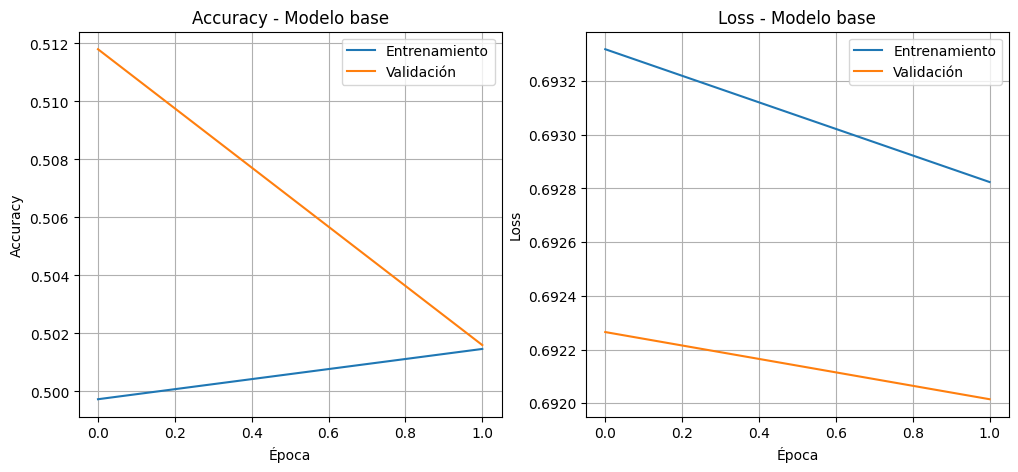

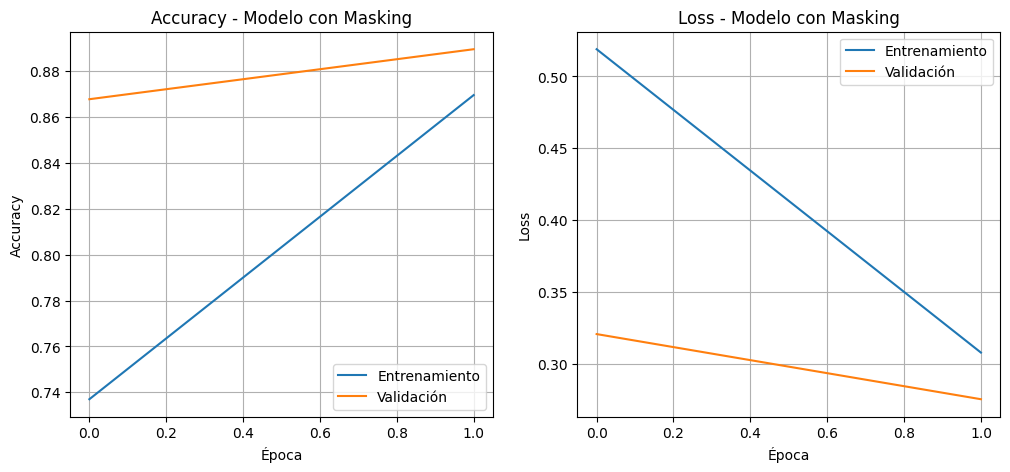

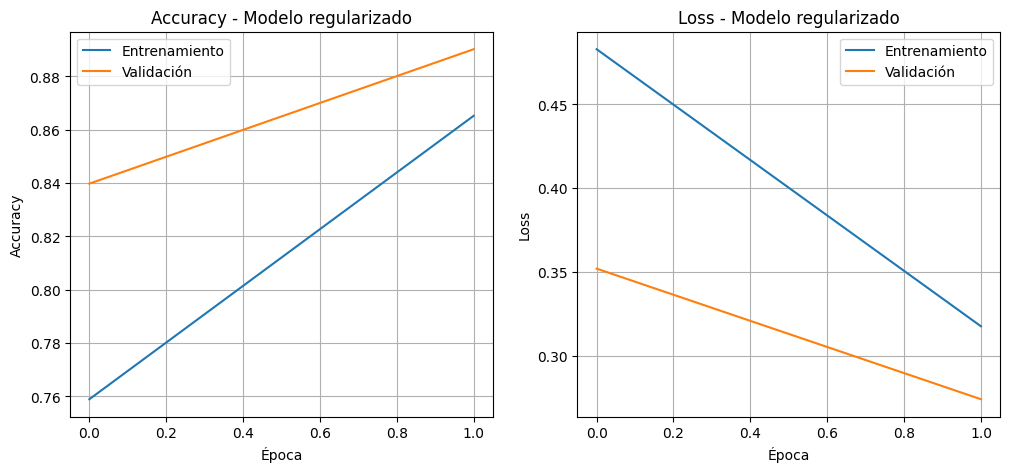

In [70]:
# Graficar curvas de accuracy y loss para los modelos entrenados
import matplotlib.pyplot as plt

# Puedes graficar para cualquier history: history, history_masking, history_reg
# Ejemplo con history (modelo base)
def plot_history(hist, title="Modelo base"):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(hist.history['accuracy'], label='Entrenamiento')
    plt.plot(hist.history['val_accuracy'], label='Validación')
    plt.title(f'Accuracy - {title}')
    plt.xlabel('Época')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1,2,2)
    plt.plot(hist.history['loss'], label='Entrenamiento')
    plt.plot(hist.history['val_loss'], label='Validación')
    plt.title(f'Loss - {title}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

# Graficar para los tres modelos si están disponibles
titles = [
    ("history", "Modelo base"),
    ("history_masking", "Modelo con Masking"),
    ("history_reg", "Modelo regularizado")
]
for hist_name, title in titles:
    if hist_name in globals():
        plot_history(eval(hist_name), title)

* El modelo cuenta con una capa de entrada de *embedding* la cual abarca la mayoría de los parámetros entrenables. En este caso un *embedding* es un vector entrenable que representa una palabra en nuevo espacio cuyo tamaño es un hiperparámetro. La concatenación de estos vectores conforma la matriz de *embedding*, donde su cantidad de filas corresponde a la suma del tamaño del vocabulario y la cantidad de columnas a las dimensiones de los vectores (*embed_size*). Al igual que una matriz de pesos, ésta se inicializa de forma aleatoria, y actualiza sus valores para cada *step* de entrenamiento.

  *   ¿Cuál es la ventaja de utilizar una capa de *embedding*? (Ver la sección *Encoding Categorical Features Using Embeddings* del *Capítulo 13* del libro.)
  *   Visualizar una representación del espacio de *embedding* utilizando *Comet*. **Importante:** para evitar errores, modifique del diccionario el valor del espacio por `<pad>`.

  Para este último punto se recomienda seguir el siguiente ejemplo: [logging-embeddings](https://www.comet.ml/docs/user-interface/embeddings/#logging-embeddings).

*   Para su mejor modelo: visualizar a qué distancias se encuentran las palabras unas de otras tanto en la representación a baja dimensión como en el espacio de *embedding*. Sobre todo probar con adjetivos positivos (*wonderful*, *excellent*, etc.) y negativos (*ugly*, *boring*, etc.) comparando los resultados. ¿Qué logra observar?.

# Parte 3: *Embedding Preentrenado*

Una de las técnicas para mejorar el desempeño en este tipo de problemas es utilizar *embeddings* ya entrenados.
Siguiendo el ejemplo [Using pre-trained word embeddings](https://keras.io/examples/nlp/pretrained_word_embeddings/):

*   Descargar el *embedding* preentrenado [GloVE](https://nlp.stanford.edu/projects/glove/) que aparece en la sección *Load pre-trained word embeddings*.

In [ ]:
# ...

* Preparar la nueva matriz de *embedding*. ¿Cuántas palabras del conjunto de entrenamiento se encuentran en el vocabulario de GloVE? ¿Cuántas no?.

In [ ]:
# ...

* Entrenar el modelo con la nueva matriz de *embedding* de manera que los valores de ésta se mantengan fijos (ver parámetro en la capa de *embedding*). Utilice masking.

In [ ]:
# ...

* Entrene nuevamente el modelo pero con el *embedding* entrenable. Modifique el *learning rate*.

In [ ]:
# ...

*   Comparar con los modelos anteriores en cuanto al desempeño, la cantidad de parámetros y el tiempo de entrenamiento.


Respuesta:

*   Visualizar cómo es el espacio de *embedding*. ¿Qué diferencias puede observar con respecto al anterior?


Respuesta:

# Parte 4: Mejoras en los Modelos

Se sugieren algunas líneas que podrían mejorar los desempeños obtenidos en las partes anteriores:

* Ampliar el tamaño del vocabulario utilizado durante el entrenamiento, junto con aumentar la complejidad del modelo.
* Implementar una función de preprocesamiento de texto que realice tareas como eliminar las etiquetas HTML, eliminar números y llevar a cabo otras acciones relevantes.
* Considerar la utilización de n-gramas y/o modificar el tokenizador utilizado.
* Evaluar el cambio de las neuronas recurrentes de GRU a LSTM.

Piense por qué tiene sentido explorar estas estrategias y pruebe alguna que considere relevante o proponga alguna otra que le parezca relevante.


In [ ]:
# ...

# Parte 5: Desarrollo de una aplicación web (Opcional)

En esta parte veremos cómo generar una aplicación web sencilla que permita mostrar el funcionamiento de un modelo que hayamos entrenado. Para ello utilizaremos la biblioteca [Streamlit](https://streamlit.io/).

## Streamlit
Streamlit es una biblioteca de código abierto escrita en Python que permite crear y compartir aplicaciones web que usan algoritmos de aprendizaje automático. En la [documentación](https://docs.streamlit.io/) encontrará información sobre cómo instalar y crear aplicaciones utilizando la biblioteca. El flujo de trabajo básico consta de los siguientes pasos:   

1. Instalación   
2. Desarrollo de la aplicación   
3. Desplieque de la aplicación

### Instalación
En la mayoría de los casos, la biblioteca debería quedar instalada luego de crear un ambiente virtual (por ejemplo de conda) y hacer:   

`pip install streamlit`  

Puede verificar que la instalación sea correcta haciendo:    

`streamlit hello`

Puede ver los detalles de instalación en https://docs.streamlit.io/library/get-started/installation

### Desarrollo de la aplicación  

Se sugiere desarrollar la aplicación partiendo de un ejemplo que clasifica críticas de cine utilizando un modelo entrenado con las técnicas vistas en el Taller 2. Dicho ejemplo puede verse en funcionamiento [acá](https://share.streamlit.io/taa-fing/taa-2022/main/apps/movie_review_app/movie_review_app.py). La siguiente celda descarga el código fuente y lo descomprime.

In [ ]:
!wget iie.fing.edu.uy/~carbajal/movie_review/apps.zip
!unzip apps.zip

Copie el archivo *movie_review_app.py*, modifique el nombre, y realice las siguientes modificaciones (además de las de diseño que crea conveniente):   

**Cambio de Modelo:**  Para hacer inferencia fuera de este *Notebook* será necesario contar con el modelo entrenado. El modelo se puede guardar con alguna de las técnicas vistas en el curso. Se sugiere utilizar el *Callback* **ModelCheckpoint**.

**Modificación del pipeline de inferencia:**  El objetivo es generar una función que a partir de una única reseña prediga si la reseña es *positiva*(1) o *negativa*(0). Para ello se brinda una función a completar

In [ ]:
# Pipeline funtion to make inference
def pipeline_inference (review, model):

  '''
  Función que prepara una review aislada y hace inferencia con el modelo.

  Entradas:
    review: String con la review a hacer inferencia
    model: Modelo entrenado con el que se realiza inferencia

  Salida:

    pred: Predicción del modelo

  '''

  # ...

  return pred

* Las siguientes celdas prueban la función. Verifique que funciona correctamente.

In [ ]:
# Load model
checkpoint_filepath = '/content/...'

model_loaded = keras.models.load_model(checkpoint_filepath)

In [ ]:
review = 'This movie is really boring. I do not recommend it.'

pred = pipeline_inference(review, model_loaded)

pred

In [ ]:
review = 'This movie is wonderful. I love it.'

pred = pipeline_inference(review, model_loaded)

pred

### Correr la aplicación localmente

Una vez realizadas las modificaciones en el archivo principal, cree un directorio donde guardar los archivos de su aplicación. Guarde allí el modelo, el archivo tipo numpy con las palabras y su archivo principal (Ej. *movie_review_app.py*).

* Una vez modificado el código, puede probarlo localmente. Para ello ejecute el siguiente comando, sustituyendo *movie_review_app.py* por el nombre de su archivo principal.


`!streamlit run apps/movie_review_app/movie_review_app.py`    

* Si en vez de localmente, está corriendo el notebook en Colab, ejecute:

`!streamlit run apps/movie_review_app/movie_review_app.py & npx localtunnel --port 80`      

### Despliegue de la aplicación

Una vez que la app fue desarrollada es posible compartirla para que otros puedan probarla. Para ello es necesario:  

1. Contar con una cuenta de [Streamlit Cloud](https://docs.streamlit.io/streamlit-cloud/get-started#sign-up-for-streamlit-cloud) y un repositorio de GitHub donde almacenar el código.
2.  Subir al repositorio  el código y los datos necesarios para correrlo.
3. [Conectar la cuenta de Streamlit Cloud con la del repositorio](https://docs.streamlit.io/streamlit-cloud/get-started#connect-your-github-account).     
4. [Publicar la app](https://docs.streamlit.io/streamlit-cloud/get-started/deploy-an-app)

*Comentario:* Puede que sea necesario agregar en el repositorio un archivo *requirements.txt* donde deba especificar las liberías utilizas en el archivo *main.py*.

# Parte 6: Uso de la liberería HuggingFace (Opcional)

Hugging Face es una organización de desarrolladores que utilizan una [plataforma](https://huggingface.co/) para compartir y desarrollar modelos de código abierto con arquitectura de Transformers, centrados principalmente en procesamiento de lenguaje natural, aunque también cuentan con modelos para procesamiento de imágenes y señales de audio.  

Los modelos son desarrollados con técnicas del estado del arte, y entrenados con grandes volumnes de datos y capacidad de computo. Cualquier persona que quiera hacer uso de los modelos pre-entrenados puede hacerlo simplemente instalando la biblioteca de Transformers y los módulos necesarios para las tareas a implementar.  

## Uso de modelo preentrenado para hacer inferencia

Este código utiliza la biblioteca de HuggingFace "transformers" para importar y utilizar un modelo preentrenado de análisis de sentimientos. En este caso, se utiliza el modelo "sentiment-analysis", que se encarga de clasificar el sentimiento de un texto dado como positivo o negativo.

In [ ]:
import sys

if "google.colab" in sys.modules:
    %pip install -q -U transformers
    %pip install -q -U datasets

In [ ]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")
result = classifier("The movie was horrible.")

In [ ]:
result

Utilizando este modelo realice inferencia sobre el conjunto de test, y evalue el desempeño obtenido. Compárelo con los obtenidos anteriormente.

In [ ]:
N_test = X_test.shape[0]

pred_test = np.zeros(N_test)

for i in range(N_test):
  result = classifier(X_test[i][:1500]) # Corta la review a 1500 caracteres para adaptarse al modelo
  if result[0]['label'] == 'NEGATIVE':
    pred_test[i] = 1 - result[0]['score']
  else:
    pred_test[i] = result[0]['score']

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, pred_test > 0.5)

## Fine-tuning de un modelo ya pre-entrenado


Para ejecutar esta parte del notebook, deberá reiniciar el entorno de ejecución.

La siguiente celda instala las bibliotecas necesarias para esta parte.

In [ ]:
%%capture
# Instalamos la biblioteca con los modelos de arquitectura Transformer
!pip install transformers
!pip install datasets
!pip install accelerate
!pip install torch

El objetivo será realizar un ajuste de parámetros al modelo utilizando los datos del problema de interés, por lo tanto la siguiente celda levanta nuevamente los datos de la críticas de cine IMBd.

In [ ]:
# Se levanta como pandas DataFrame (Se requiere tener el csv descargado de la página de Kaggle)
data_file = 'IMDB Dataset.csv'
data = pd.read_csv(data_file)

# Reduce el largo de las reviews a 1500 caracteres
data['review'] = data['review'].str[:1500]

# Convierte las etiquetas de sentimiento a 1 y 0
data['sentiment'] = data['sentiment'].map({'positive': 1, 'negative': 0})

# Print los datos actualizados
print(data.head())

In [ ]:
data.iloc[0]['review']

**Armado de Conjuntos** Se arman los datasets de Torch para realizar el entrenamiento.

In [ ]:
import datasets

# Convertir los pandas DataFrames a datasets
train_data = datasets.Dataset.from_pandas(data[:20000]) # Se cortan la cantidad de reseñas para reducir el costo computacional de la ejecucción.
val_data = datasets.Dataset.from_pandas(data[30000:35000])
test_data = datasets.Dataset.from_pandas(data[35000-1:])

# Renombrar las columnas para que coincidan con los nombres esperados por el modelo
train_data = train_data.rename_column("sentiment", "label")
val_data = val_data.rename_column("sentiment", "label")
test_data = test_data.rename_column("sentiment", "label")
train_data = train_data.rename_column("review", "text")
val_data = val_data.rename_column("review", "text")
test_data = test_data.rename_column("review", "text")

# Crear un DatasetDict
emotions = datasets.DatasetDict({
    "train": train_data,
    "validation": val_data,
    "test": test_data
})

In [ ]:
train_ds = emotions["train"]
train_ds

In [ ]:
train_ds[0]

**Preparación de los datos** Los datos se pasan por el mismo tokenizer que se uso para el modelo de base que se utilizará. HuggingFace tiene un método "AutoTokenizer" para esto (simplemente determina cual es el tokenizer para ese modelo y lo aplica)

In [ ]:
from transformers import AutoTokenizer

model_ckpt='distilbert-base-uncased'

tokenizer = AutoTokenizer.from_pretrained(model_ckpt)

Finalmente implementamos una función para aplicar el tokenizer a todo el conjunto de datos

In [ ]:
def tokenize(batch):
  return tokenizer(batch['text'], padding=True,truncation=True)


In [ ]:
emotions_encoded = emotions.map(tokenize,batched=True,batch_size=None)

 **Fine-tuning de un modelo**

 En primer lugar se levanta el modelo a ajustar y luego se procede a entrenarlo.

In [ ]:
from transformers import AutoModelForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_labels = 6

model = (AutoModelForSequenceClassification.from_pretrained(model_ckpt,num_labels = num_labels).to(device))

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels,preds,average="weighted")
  acc = accuracy_score(labels,preds)
  return {"accuracy": acc, "f1": f1}

In [ ]:
from transformers import Trainer, TrainingArguments

batch_size = 32
logging_steps = len(emotions_encoded["train"])
model_name = f"{model_ckpt}-finetuned-emotions"
training_args = TrainingArguments(output_dir = model_name,
                                  num_train_epochs = 2,
                                  learning_rate= 2e-5,
                                  per_device_train_batch_size=batch_size,
                                  per_device_eval_batch_size=batch_size,
                                  weight_decay=0.01,
                                  evaluation_strategy="epoch",
                                  disable_tqdm=False,
                                  logging_steps=logging_steps,
                                  push_to_hub=False,
                                  log_level="error")

In [ ]:
trainer = Trainer(model=model,
                  args=training_args,
                  compute_metrics = compute_metrics,
                  train_dataset=emotions_encoded["train"],
                  eval_dataset = emotions_encoded["validation"],
                  tokenizer=tokenizer)

trainer.train()

In [ ]:
preds_output = trainer.predict(emotions_encoded["test"])

In [ ]:
preds_output.metrics